# 10 回溯

## 10.1 全排列

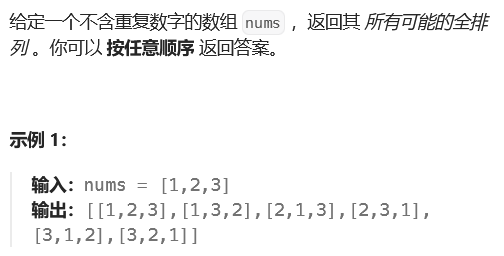

In [ ]:
class Solution:
    def permute(self, nums: List[int]) -> List[List[int]]:
        res = []
        def backtrack(start):
            if start == len(nums):
                res.append(nums.copy())
                return
            for i in range(start, len(nums)):
                nums[start], nums[i] = nums[i], nums[start]  # 交换
                backtrack(start + 1)
                nums[start], nums[i] = nums[i], nums[start]  # 撤销交换
        backtrack(0)
        return res

In [4]:
def func(nums):
    res = []
    def backtrack(start):
        if start == len(nums):
            res.append(nums.copy())
            print(res)
            return
        for i in range(start,len(nums)):
            nums[i],nums[start] = nums[start],nums[i]
            print('交换前:',f'start={start} i={i}')
            # print(nums)
            backtrack(start+1)
            print('交换后:',f'start={start} i={i}')
            # print(nums)
            nums[i],nums[start] = nums[start],nums[i]
    backtrack(0)
    return res
print(func([1,2,3]))


交换前: start=0 i=0
交换前: start=1 i=1
交换前: start=2 i=2
[[1, 2, 3]]
交换后: start=2 i=2
交换后: start=1 i=1
交换前: start=1 i=2
交换前: start=2 i=2
[[1, 2, 3], [1, 3, 2]]
交换后: start=2 i=2
交换后: start=1 i=2
交换后: start=0 i=0
交换前: start=0 i=1
交换前: start=1 i=1
交换前: start=2 i=2
[[1, 2, 3], [1, 3, 2], [2, 1, 3]]
交换后: start=2 i=2
交换后: start=1 i=1
交换前: start=1 i=2
交换前: start=2 i=2
[[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1]]
交换后: start=2 i=2
交换后: start=1 i=2
交换后: start=0 i=1
交换前: start=0 i=2
交换前: start=1 i=1
交换前: start=2 i=2
[[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1], [3, 2, 1]]
交换后: start=2 i=2
交换后: start=1 i=1
交换前: start=1 i=2
交换前: start=2 i=2
[[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1], [3, 2, 1], [3, 1, 2]]
交换后: start=2 i=2
交换后: start=1 i=2
交换后: start=0 i=2
[[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1], [3, 2, 1], [3, 1, 2]]


## 10.2 子集

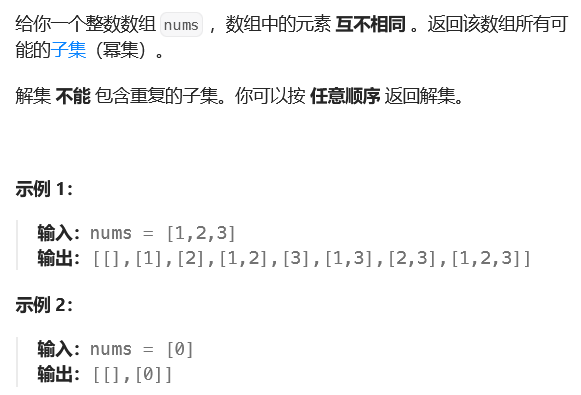

In [ ]:
class Solution:
    def subsets(self, nums: List[int]) -> List[List[int]]:
        res = []   # 最终存所有子集
        path = []  # 临时记录当前选了哪些数

        # 回溯函数：start=本次只能从nums[start]开始选
        def backtrack(start):
            # 1. 先把现在path里的数保存一份到结果
            # 必须copy！不然后面path变了，res里的内容也会跟着变
            res.append(path.copy())

            # 2. 循环：从start到数组末尾逐个尝试拿数字
            for i in range(start, len(nums)):
                path.append(nums[i])   # 选当前nums[i]，加入path
                backtrack(i + 1)       # 递归：下一轮只能选i后面的数字（i+1）
                path.pop()             # 回溯！撤销刚才选的nums[i]，试下一个数字

        backtrack(0)  # 从下标0开始选
        return res

## 10.3 电话号码的字母组合

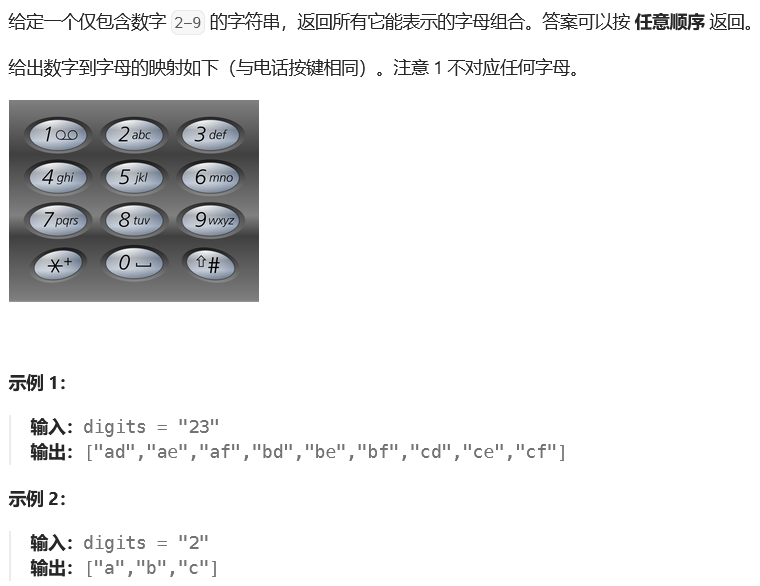

In [ ]:
class Solution:
    def letterCombinations(self, digits: str) -> List[str]:
        if not digits:
            return []
        
        # 数字字母映射
        phone = {
            "2": "abc",
            "3": "def",
            "4": "ghi",
            "5": "jkl",
            "6": "mno",
            "7": "pqrs",
            "8": "tuv",
            "9": "wxyz"
        }
        res = []

        def backtrack(index, path):
            # 终止条件：拼完所有数字
            if index == len(digits):
                res.append(path)
                return
            # 当前数字对应的字母列表
            chars = phone[digits[index]]
            for c in chars:
                backtrack(index + 1, path + c)
        
        backtrack(0, "")
        return res

## 10.4 组合总和

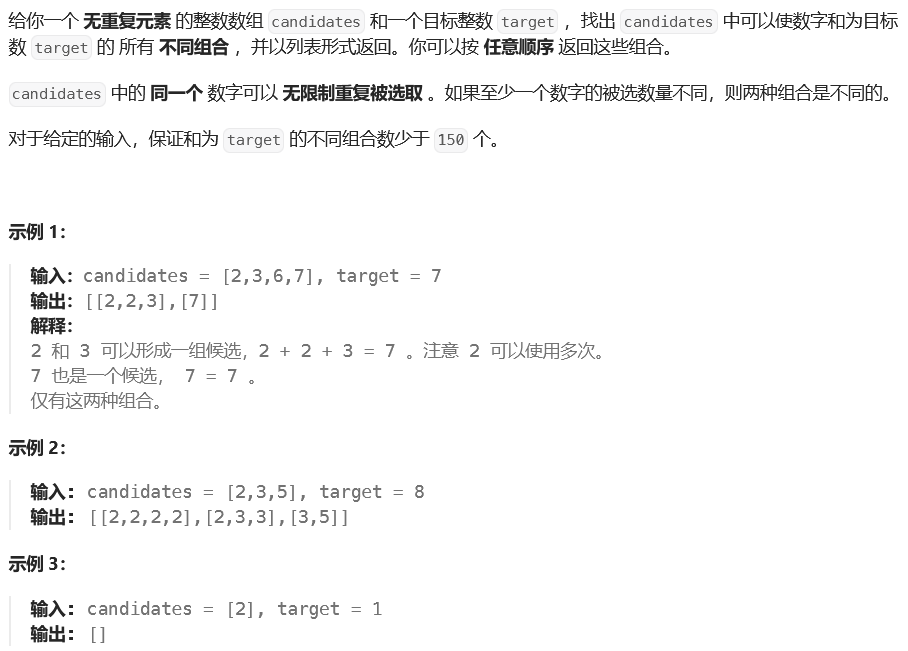

In [ ]:
class Solution:
    def combinationSum(self, candidates: List[int], target: int) -> List[List[int]]:
        res = []
        def backtrack(start, path, cur_sum):
            # 终止：和等于目标，存入结果
            if cur_sum == target:
                res.append(path.copy())
                return
            # 和超了，剪枝
            if cur_sum > target:
                return
            # 从start开始遍历，避免重复组合
            for i in range(start, len(candidates)):
                num = candidates[i]
                path.append(num)
                # 可以重复选，下一轮还是从i开始
                backtrack(i, path, cur_sum + num)
                # 回溯撤销
                path.pop()
        
        backtrack(0, [], 0)
        return res

## 10.5 括号生成

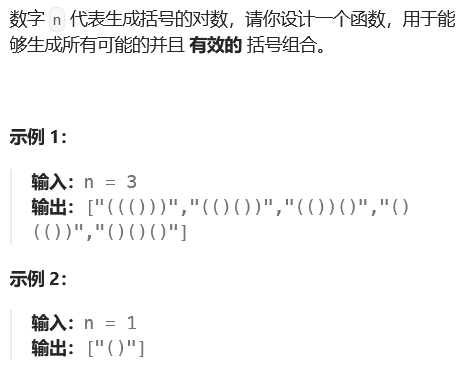

In [ ]:
class Solution:
    def generateParenthesis(self, n: int) -> List[str]:
        res = []
    
        def backtrack(path, left, right):
            # 终止条件：凑齐n对
            if left == n and right == n:
                res.append(path)
                return
            # 还能放左括号
            if left < n:
                backtrack(path + "(", left + 1, right)
            # 右括号少于左括号，才能放右括号
            if right < left:
                backtrack(path + ")", left, right + 1)
        
        backtrack("", 0, 0)
        return res

## 10.6 单词搜索

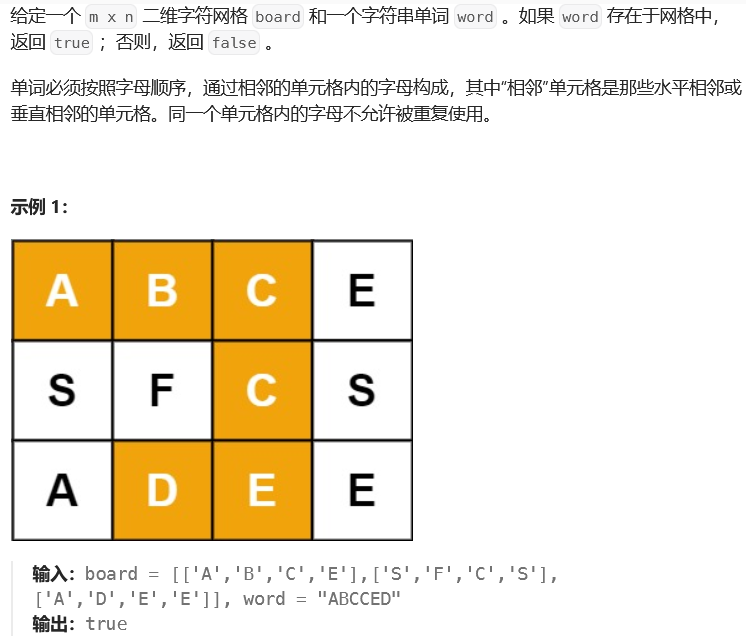

In [ ]:
class Solution:
    def exist(self, board: List[List[str]], word: str) -> bool:
        m = len(board)
        n = len(board[0])
        
        def dfs(i, j, idx):
            # 匹配完整个单词，找到路径
            if idx == len(word):
                return True
            # 越界 或 字符不匹配
            if i < 0 or i >= m or j < 0 or j >= n or board[i][j] != word[idx]:
                return False
            
            # 标记已访问，临时存原字符
            temp = board[i][j]
            board[i][j] = '#'
            
            # 上下左右四个方向搜索
            res = dfs(i+1, j, idx+1) or dfs(i-1, j, idx+1) or \
                dfs(i, j+1, idx+1) or dfs(i, j-1, idx+1)
            
            # 回溯恢复
            board[i][j] = temp
            return res
        
        # 遍历所有起点
        for i in range(m):
            for j in range(n):
                if board[i][j] == word[0]:
                    if dfs(i, j, 0):
                        return True
        return False

## 10.7 分割回文串

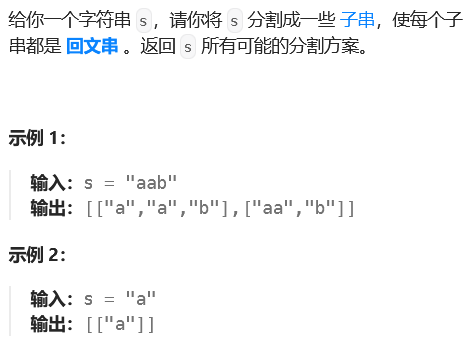

In [ ]:
class Solution:
    def partition(self, s: str) -> List[List[str]]:
        res = []
        n = len(s)

        # 判断是否回文
        def is_pal(l, r):
            while l < r:
                if s[l] != s[r]:
                    return False
                l += 1
                r -= 1
            return True

        def backtrack(start, path):
            # 分割完整个字符串，记录答案
            if start == n:
                res.append(path.copy())
                return
            # 枚举分割终点
            for end in range(start, n):
                if is_pal(start, end):
                    path.append(s[start:end+1])
                    backtrack(end + 1, path)
                    path.pop()
        
        backtrack(0, [])
        return res

## 10.8 N 皇后

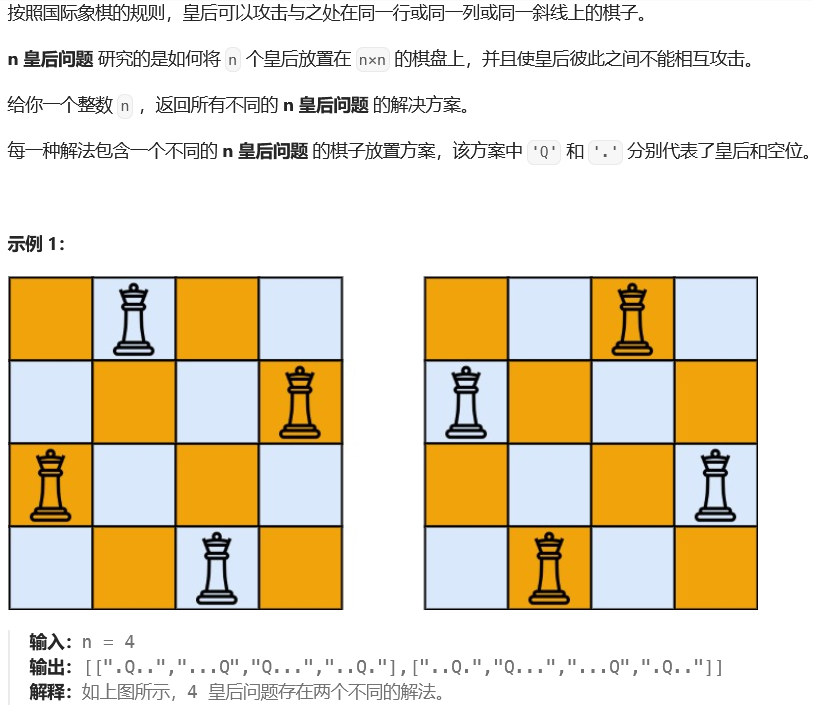

In [ ]:
class Solution:
    def solveNQueens(self, n: int) -> List[List[str]]:
        res = []
        # 记录每一行皇后放在第几列
        path = []
        cols = set()
        diag1 = set()
        diag2 = set()

        def backtrack(row):
            # 终止：所有行放完
            if row == n:
                board = ["." * col + "Q" + "." * (n - col - 1) for col in path]
                res.append(board)
                return
            # 枚举当前行所有列
            for col in range(n):
                d1 = row - col
                d2 = row + col
                if col not in cols and d1 not in diag1 and d2 not in diag2:
                    # 放置皇后
                    path.append(col)
                    cols.add(col)
                    diag1.add(d1)
                    diag2.add(d2)
                    backtrack(row + 1)
                    # 回溯撤销
                    path.pop()
                    cols.remove(col)
                    diag1.remove(d1)
                    diag2.remove(d2)
        
        backtrack(0)
        return res